<a href="https://colab.research.google.com/github/phevyy/Dizi/blob/main/DerinOgrenme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Sürümü: 2.20.0
Kullanılabilir GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Veri seti indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:38<00:00, 17.8MB/s]

Zip dosyası çıkarılıyor...
Çıkarma tamamlandı.

Kullanılacak veri dizini: /content/plant_data/PlantVillage
Tespit edilen sınıflar: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.

Toplam sınıf sayısı: 15


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


=== AŞAMA 1: Feature Extraction başlıyor ===

Epoch 1/15
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 60s 41ms/step - accuracy: 0.4696 - loss: 1.7190 - val_accuracy: 0.7226 - val_loss: 1.0463 - learning_rate: 1.0000e-04
Epoch 2/15
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 50s 42ms/step - accuracy: 0.7228 - loss: 0.9319 - val_accuracy: 0.7800 - val_loss: 0.7559 - learning_rate: 1.0000e-04
Epoch 3/15
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.7829 - loss: 0.7188 - val_accuracy: 0.8202 - val_loss: 0.6197 - learning_rate: 1.0000e-04
Epoch 4/15
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.8127 - loss: 0.6140 - val_accuracy: 0.8403 - val_loss: 0.5453 - learning_rate: 1.0000e-04
Epoch 5/15
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 47s 39ms/step - accuracy: 0.8306 - loss: 0.5514 - val_accuracy: 0.8527 - val_loss: 0.4978 - learning_rate: 1.0000e-04
Epoch 6/15
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 47s 39ms/step - accuracy: 0.8391 - loss: 0.5114 - val_accuracy: 0.8599 - val_loss: 0.4719 - learning_rate: 1.00

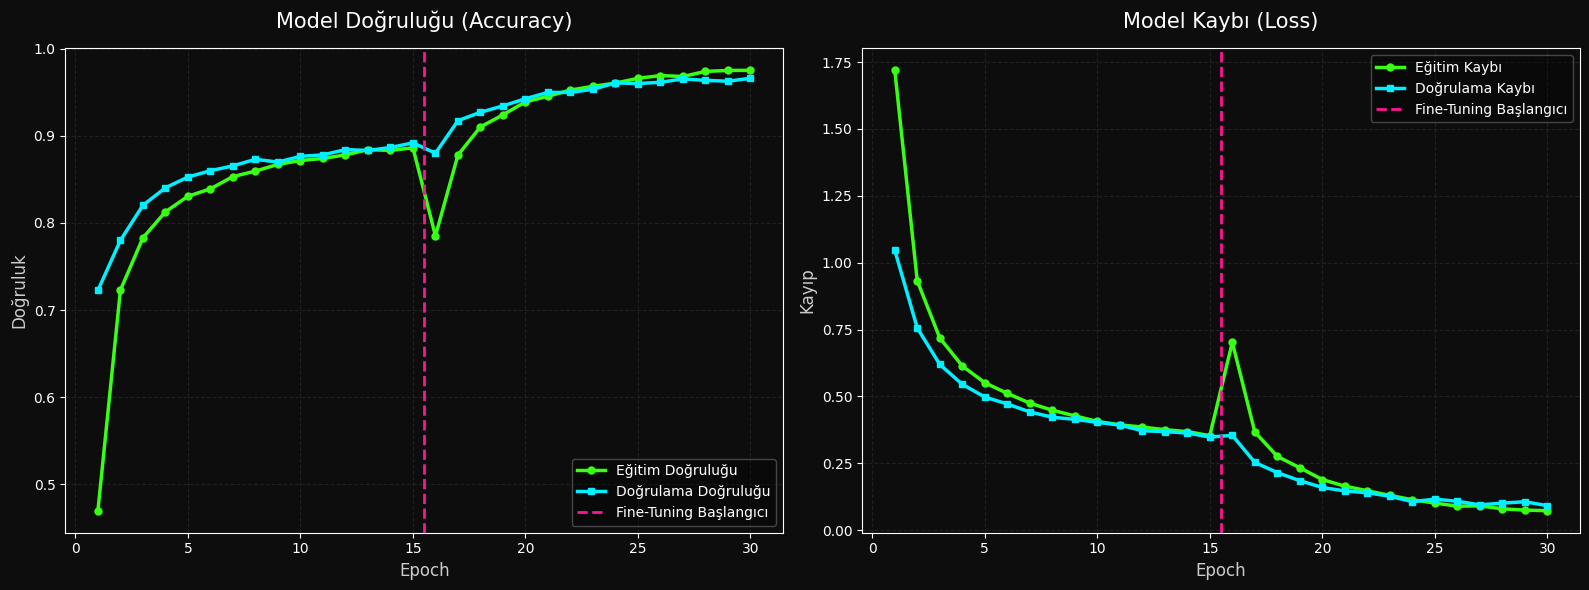


--- SONUÇ ÖZETİ ---
En İyi Doğrulama Doğruluğu : 96.61%
Son Doğrulama Doğruluğu    : 96.61%
Son Eğitim Doğruluğu       : 97.52%


In [2]:
# =============================================================================
# BÖLÜM 1: KURULUM VE KÜTÜPHANELER
# =============================================================================
!pip install -q kaggle

import os
import zipfile
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow Sürümü:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("Kullanılabilir GPU:", gpus if gpus else "GPU BULUNAMADI! (Runtime > Change runtime type > T4 GPU seçin)")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Bellek ayarı atlandı:", e)

# =============================================================================
# BÖLÜM 2: KAGGLE API İLE VERİ İNDİRME
# =============================================================================
os.environ['KAGGLE_USERNAME'] = "fikretemresnmaz"
os.environ['KAGGLE_KEY']      = "KGAT_46f9b07e77dade38cc6ec8276b02b1db"

print("\nVeri seti indiriliyor...")
!kaggle datasets download -d emmarex/plantdisease -p /content --force

zip_path = "/content/plantdisease.zip"
extract_path = "/content/plant_data"

print("Zip dosyası çıkarılıyor...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Çıkarma tamamlandı.")

# =============================================================================
# BÖLÜM 3: VERİ KLASÖR YOLUNU OTOMATİK BULMA
# =============================================================================
def klasor_yolunu_bul(kok_dizin):
    en_iyi_yol = kok_dizin
    en_fazla_sinif = 0
    for dirpath, dirnames, filenames in os.walk(kok_dizin):
        alt_klasor_sayisi = len([d for d in dirnames if os.path.isdir(os.path.join(dirpath, d))])
        if alt_klasor_sayisi > en_fazla_sinif:
            ornek_klasor = os.path.join(dirpath, dirnames[0])
            ornek_dosyalar = os.listdir(ornek_klasor)
            if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in ornek_dosyalar):
                en_fazla_sinif = alt_klasor_sayisi
                en_iyi_yol = dirpath
    return en_iyi_yol

DATA_DIR = klasor_yolunu_bul(extract_path)
print(f"\nKullanılacak veri dizini: {DATA_DIR}")
print(f"Tespit edilen sınıflar: {sorted(os.listdir(DATA_DIR))}")

# =============================================================================
# BÖLÜM 4: VERİ ÖN İŞLEME (tf.data Pipeline)
# =============================================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"\nToplam sınıf sayısı: {NUM_CLASSES}")

train_ds = train_ds.shuffle(500).prefetch(buffer_size=2)
val_ds   = val_ds.prefetch(buffer_size=2)

# =============================================================================
# BÖLÜM 5: DATA AUGMENTATION (Veri Artırma)
# =============================================================================
# Görüntülere rastgele dönüşümler uygulayarak modelin daha iyi genelleme
# yapmasını sağlıyoruz. Overfitting'iniz olmadığı için HAFİF tutuyoruz:
# aşırı agresif augmentation öğrenmeyi yavaşlatabilir.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),      # Yatay çevirme
    tf.keras.layers.RandomRotation(0.1),            # ±%10 döndürme
    tf.keras.layers.RandomZoom(0.1),                # ±%10 zoom
], name="data_augmentation")

# =============================================================================
# BÖLÜM 6: MODEL MİMARİSİ (Transfer Learning - MobileNetV2)
# =============================================================================
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet'
)
# AŞAMA 1: Taban tamamen donuk
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)                       # Önce augmentation
x = preprocess_input(x)                             # Sonra ön işleme
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# =============================================================================
# BÖLÜM 7: AŞAMA 1 - FEATURE EXTRACTION (Üst katmanları eğit)
# =============================================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# Callback'ler: en iyi noktada durdur ve öğrenme oranını otomatik ayarla
callbacks_asama1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4,
        restore_best_weights=True  # Eğitim biterken en iyi ağırlıkları geri yükle
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
    )
]

EPOCHS_ASAMA1 = 15
print("\n=== AŞAMA 1: Feature Extraction başlıyor ===\n")
history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_ASAMA1, callbacks=callbacks_asama1
)

# =============================================================================
# BÖLÜM 8: AŞAMA 2 - FINE-TUNING (Tabanın üst katmanlarını çöz)
# =============================================================================
# Tabanı eğitilebilir yapıyoruz, AMA sadece SON katmanları.
# İlk katmanlar (genel özellikler: kenar, doku) donuk kalır;
# son katmanlar (özelleşmiş özellikler) yaprak hastalıklarına uyum sağlar.
base_model.trainable = True

# MobileNetV2'nin 154 katmanı var. İlk 100'ünü donuk tutuyoruz.
FINE_TUNE_AT = 100
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

print(f"\nToplam katman: {len(base_model.layers)} | Eğitilebilir katman: {len(base_model.layers) - FINE_TUNE_AT}")

# ÇOK DÜŞÜK learning rate ile yeniden derle (fine-tuning'in altın kuralı).
# Yüksek LR, önceden öğrenilmiş değerli ağırlıkları bozar.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 10x daha düşük
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_asama2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7
    )
]

EPOCHS_ASAMA2 = 15
print("\n=== AŞAMA 2: Fine-Tuning başlıyor ===\n")
history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_ASAMA2, callbacks=callbacks_asama2
)

# =============================================================================
# GÖRSELLEŞTİRME
# =============================================================================
acc      = history1.history['accuracy'] + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
epochs_range = range(1, len(acc) + 1)
asama_gecis = len(history1.history['accuracy'])  # Fine-tuning

plt.style.use('dark_background')
NEON_GREEN = '#39FF14'
NEON_BLUE  = '#00F0FF'
NEON_PINK  = '#FF1493'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d0d')

ax1 = axes[0]
ax1.set_facecolor('#0d0d0d')
ax1.plot(epochs_range, acc, color=NEON_GREEN, linewidth=2.5, marker='o', markersize=5, label='Eğitim Doğruluğu')
ax1.plot(epochs_range, val_acc, color=NEON_BLUE, linewidth=2.5, marker='s', markersize=5, label='Doğrulama Doğruluğu')
ax1.axvline(x=asama_gecis + 0.5, color=NEON_PINK, linestyle='--', linewidth=2, label='Fine-Tuning Başlangıcı')
ax1.set_title('Model Doğruluğu (Accuracy)', fontsize=15, color='white', pad=15)
ax1.set_xlabel('Epoch', fontsize=12, color='#cccccc')
ax1.set_ylabel('Doğruluk', fontsize=12, color='#cccccc')
ax1.legend(loc='lower right', framealpha=0.3)
ax1.grid(True, color='#333333', linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor('#0d0d0d')
ax2.plot(epochs_range, loss, color=NEON_GREEN, linewidth=2.5, marker='o', markersize=5, label='Eğitim Kaybı')
ax2.plot(epochs_range, val_loss, color=NEON_BLUE, linewidth=2.5, marker='s', markersize=5, label='Doğrulama Kaybı')
ax2.axvline(x=asama_gecis + 0.5, color=NEON_PINK, linestyle='--', linewidth=2, label='Fine-Tuning Başlangıcı')
ax2.set_title('Model Kaybı (Loss)', fontsize=15, color='white', pad=15)
ax2.set_xlabel('Epoch', fontsize=12, color='#cccccc')
ax2.set_ylabel('Kayıp', fontsize=12, color='#cccccc')
ax2.legend(loc='upper right', framealpha=0.3)
ax2.grid(True, color='#333333', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, facecolor='#0d0d0d')
plt.show()

# =============================================================================
# BÖLÜM 10: SONUÇ ÖZETİ
# =============================================================================
print(f"\n{'='*45}")
print(f"--- SONUÇ ÖZETİ ---")
print(f"{'='*45}")
print(f"En İyi Doğrulama Doğruluğu : {max(val_acc)*100:.2f}%")
print(f"Son Doğrulama Doğruluğu    : {val_acc[-1]*100:.2f}%")
print(f"Son Eğitim Doğruluğu       : {acc[-1]*100:.2f}%")
print(f"{'='*45}")